# NCA 电池 SOH 预测 — 全量数据 MLP 深度集成（为迁移到 LFP 做准备）

**为什么用这个算法**：你有几百块电池、要求"用满全部数据不丢弃"，还要迁移到 LFP。
神经网络（MLP）用小批量 SGD 训练，**每个 epoch 都过一遍全部样本**（复杂度 O(N)，几十万行也没问题），
天然满足数据完整性；它的"特征提取器 + 回归头"结构又支持"冻结特征提取器、只重训头"的迁移。

在此基础上，用两个技巧补回 GPR 的优点：
- **深度集成**（训 K 个 MLP）→ 均值作预测、跨模型标准差作**不确定度**，顺带提升精度；
- **置换重要性**（permutation importance）→ 得到类似 **ARD 的特征相关性**。

同时保留一个 **GBDT 基线**：表格数据上原始精度常更高、也用满全部数据，但**不支持冻结/微调式迁移**。
所以——**要迁移用 MLP 集成；只看 NCA 单任务精度看 GBDT。**

**输入**：`OCV (V)`, `R0 (Ohm)`, `R1 (Ohm)`, `tau1 (s)`, `R2 (Ohm)`, `tau2 (s)`
｜ **输出**：`SOH (%)`

---
### 本版相对原始 notebook 的改动（调试记录，便于对照）
1. **P0 修复**：补上 `permutation_importance` 的 import；`cell 18` 保存时把不存在的 `gb`
   改成实际训练出的 `xgb`；同时补上原本缺失的 `HAS_TORCH` 定义（torch 是无条件 import 的，直接置 `True`）。
2. **训练提速**：`batch_size` 256→4096，配合 `ReduceLROnPlateau` 学习率调度，`epochs`/`patience` 相应缩短——
   原配置在 CPU 上一次完整训练要几十小时，是"调参数没用"的头号原因，根源是训练根本没跑完。
3. **缩小网络容量 + 加正则**：`hidden` 从 `(256,128,64)` 降到 `(128,64,32)`，`dropout` 0.1→0.25，
   `weight_decay` 1e-4→3e-4，配合 BatchNorm + GELU，专门针对"train 好、test 差"的过拟合。
4. **诊断补全**：训练集 R²（欠拟合/过拟合判断）、loss 曲线、MLP 专属置换重要性（区别于 XGBoost 的重要性）、
   特征相关性矩阵、 噪声敏感度检查、误差最大样本定位（按电池 + 按 SOH 区间）、
   `GroupKFold` 5 折交叉验证（比单次切分更能反映真实泛化能力）。
5. **工况自动解析**：移除手工工况字典，直接从 `cell_id` 或 `source_file` 中解析
   `温度grad_SOC_DOD`，例如 `VTC6_003_25grad_70SOC_60DOD` → `25grad_70soc_60dod`。

6. **本次改动（v2）**：
   - **温度来源**：不再从文件名解析，改为读取数据文件中的 `Temperature (°C)` 列
     （`TEMPERATURE_SOURCE="column"`，可切回 `"filename"`）。
   - **数据划分**：固定采用按电池分组的随机 train/val/test 划分，避免同一块电池跨集合泄漏。
   - **保存产物**：第 7 节真正落盘 `nca_artifacts/`（集成权重 + scaler + 结构超参），
     供迁移学习 notebook `lfp_transfer_learning.ipynb` 加载。


In [12]:
import os, re
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# 固定随机种子
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# 全局配置
plt.rcParams["figure.figsize"] = (6, 4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HAS_TORCH = True

print(f"🚀 环境就绪 | PyTorch: {torch.__version__} | 训练设备: {device}")

🚀 环境就绪 | PyTorch: 2.13.0+cu126 | 训练设备: cuda


## 1. 配置

`DATA_ROOT` 指向包含各电池文件夹的根目录。

**改动 1（温度来源）**：温度不再从文件名里的 `25grad` 解析，而是**直接读取数据文件中的
`Temperature (°C)` 列**。`TEMPERATURE_SOURCE="column"` 为新逻辑；若想回到旧行为，
把它改成 `"filename"` 即可。列名写法不一致（`Temperature(C)` / `Temp` 等）会被
`resolve_temperature_column()` 自动归一到 `TEMPERATURE_COL`。

`read_one_file()` 仍然是**唯一需要按数据内容格式调整**的地方。


In [13]:
# 数据路径
DATA_ROOT = r"C:\Users\huang\OneDrive\桌面\output_rc_soh_1_300_mixed_conditions"

# 温度列名（数据文件中已存在）
TEMPERATURE_COL = "Temperature (°C)"

# 特征与目标列（已移除 OCV）
FEATURES = ["R0 (Ohm)", "R1 (Ohm)", "tau1 (s)", "R2 (Ohm)", "tau2 (s)", TEMPERATURE_COL]
TARGET = "SOH (%)"

# 对数变换配置
LOG_TAU_COLS = ["tau1 (s)", "tau2 (s)"]
USE_LOG_TAU = False

# 时间解析
TIME_RE = re.compile(r"(\d{8})_(\d{6})")

def parse_time_from_name(fname):
    """从文件名解析时间戳"""
    m = TIME_RE.search(fname)
    return datetime.strptime(f"{m.group(1)}{m.group(2)}", "%Y%m%d%H%M%S") if m else None

def read_one_file(fpath):
    """读取单个数据文件，并清理列名中的 BOM 和空格"""
    d = pd.read_csv(fpath, sep=None, engine="python")

    d.columns = (
        d.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )

    return d


print(f"✅ 配置完成 | 特征列: {FEATURES}")

✅ 配置完成 | 特征列: ['R0 (Ohm)', 'R1 (Ohm)', 'tau1 (s)', 'R2 (Ohm)', 'tau2 (s)', 'Temperature (°C)']


## 2. 遍历所有电池文件夹并合并

找不到 `DATA_ROOT` 时用**多电池合成数据**（默认 300 块）演示，模拟你的规模。

In [14]:
def file_time_key(fpath):
    """按照文件名中的时间戳排序；无法解析时直接报错"""
    ts = parse_time_from_name(fpath.name)

    if ts is None:
        raise ValueError(
            f"文件名中未找到时间戳：{fpath.name}，"
            "期望格式类似 YYYYMMDD_HHMMSS"
        )

    return ts

def load_all_batteries(root):
    """遍历 root 下每个电池文件夹，读取其中所有循环文件并合并。
    温度直接从数据文件的 'Temperature (°C)' 列读取。
    """
    root = Path(root)
    frames = []
    
    for cell_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        cell_id = cell_dir.name
        files = sorted(
    (
        f for f in cell_dir.iterdir()
        if f.is_file()
    ),
    key=file_time_key
)

        
        for order, f in enumerate(files):
            try:
                d = read_one_file(f).copy()
            except Exception as e:
                print(f"跳过 {f.name} -> {e}")
                continue
            
            # 添加元数据列
            d["cell_id"] = cell_id
            d["file_time"] = parse_time_from_name(f.name)
            d["file_order"] = order
            d["source_file"] = f.name
            
            # 确保温度列存在
            if TEMPERATURE_COL not in d.columns:
                raise KeyError(
                    f"文件 {f.name} 中未找到温度列 '{TEMPERATURE_COL}'，"
                    f"实际列名: {d.columns.tolist()}"
                )
            
            frames.append(d)
    
    if not frames:
        raise RuntimeError("没读到任何文件，请检查 DATA_ROOT 和 read_one_file()")
    
    return pd.concat(frames, ignore_index=True)


# 加载数据
df = load_all_batteries(DATA_ROOT)

# 温度列数值化（处理可能的格式问题）
df[TEMPERATURE_COL] = pd.to_numeric(
    df[TEMPERATURE_COL].astype(str).str.strip().str.replace(",", ".", regex=False),
    errors="coerce"
)

# 检查温度缺失
if df[TEMPERATURE_COL].isna().any():
    bad = df.loc[df[TEMPERATURE_COL].isna(), ["cell_id", "source_file"]].drop_duplicates()
    raise ValueError(
        f"以下文件的温度列存在空值/无法解析为数值（共 {len(bad)} 个文件）：\n"
        f"{bad.head(20).to_string(index=False)}"
    )

# 数据概况
print(f"总样本 N = {len(df)}，电池数 = {df['cell_id'].nunique()}")
print("温度分布：")
print(df[TEMPERATURE_COL].describe().round(3).to_string())
print("出现过的温度取值：", sorted(df[TEMPERATURE_COL].round(1).unique())[:20])
df.head()

总样本 N = 902984，电池数 = 230
温度分布：
count    902984.000
mean         29.947
std           8.381
min          11.550
25%          25.660
50%          26.335
75%          35.782
max          50.757
出现过的温度取值： [np.float64(11.6), np.float64(12.5), np.float64(12.7), np.float64(12.9), np.float64(13.0), np.float64(13.1), np.float64(13.2), np.float64(13.3), np.float64(13.4), np.float64(13.5), np.float64(13.6), np.float64(13.7), np.float64(13.8), np.float64(13.9), np.float64(14.0), np.float64(14.1), np.float64(14.2), np.float64(14.3), np.float64(14.4), np.float64(14.5)]


,segment_id,SOH (%),OCV (V),R0 (Ohm),R1 (Ohm),tau1 (s),R2 (Ohm),tau2 (s),Temperature (°C),cell_id,file_time,file_order,source_file
0,1,"96,1","4,11152","0,023761","0,021848","27,7","0,015772","223,85",25.8927,VTC6_003_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...
1,2,"96,0807","4,1111","0,024373","0,021893","28,47","0,015407","222,14",25.8457,VTC6_003_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...
2,3,"96,0614","4,111268","0,024156","0,021858","27,57","0,015542","217,0",25.8863,VTC6_003_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...
3,4,"96,0421","4,111116","0,024298","0,021961","28,0","0,015399","220,12",25.8415,VTC6_003_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...
4,5,"96,0228","4,111059","0,024553","0,021858","28,78","0,015212","223,46",25.8467,VTC6_003_70SOC_60DOD,2024-09-09 11:00:48,0,VTC6_003_20240909_110048_25grad_70SOC_60DOD_c5...


## 3. 预处理 + 划分

- tau 做 log 变换；`StandardScaler` **只在训练集 fit**。
- 对全部样本按电池分组随机划分 train/val/test，避免同一块电池同时出现在不同集合。
- `RANDOM_SPLIT_BY_CELL=True` 时按电池划分；如果改为 `False`，会产生同一电池跨集合的数据泄漏。
- **不做任何子采样**——全部样本都进入训练。
- 原始 MLP 与 Temporal Transformer 使用同一组电池级划分，便于公平比较。


In [15]:
# ==================== 1. 数据清洗与数值类型转换 ====================
numeric_cols = list(dict.fromkeys(FEATURES + [TARGET]))

for col in numeric_cols:
    if col not in df.columns:
        raise KeyError(f"数据中缺少列：{col}")
    
    # 清洗并转换为数值
    cleaned = df[col].astype(str).str.strip().str.replace(",", ".", regex=False)
    df[col] = pd.to_numeric(cleaned, errors="coerce")

# 检查缺失值
invalid = df[numeric_cols].isna().sum()
invalid = invalid[invalid > 0]
if not invalid.empty:
    print(f"⚠️ 以下列存在空值/无法解析：\n{invalid.sort_values(ascending=False)}")

# 剔除缺失值
data = df.dropna(subset=numeric_cols).copy().reset_index(drop=True)

# ==================== 2. 特征工程：对数变换 ====================
if USE_LOG_TAU:
    for c in LOG_TAU_COLS:
        data[c] = np.log(data[c])

# 构建特征和目标
X = data[FEATURES].values.astype(np.float32)
y = data[TARGET].values.astype(np.float32)
groups = data["cell_id"].values

# ==================== 3. 数据划分 ====================
RANDOM_TEST_RATIO = 0.20
RANDOM_VAL_RATIO = 0.20
RANDOM_SPLIT_BY_CELL = True

def make_random_split(test_ratio=0.20, val_ratio=0.20, by_cell=True, seed=42, verbose=True):
    """随机划分数据集"""
    n = len(X)
    all_idx = np.arange(n)
    
    if by_cell:
        # 按电池分组划分
        gss1 = GroupShuffleSplit(n_splits=1, test_size=test_ratio, random_state=seed)
        tv_idx, test_idx = next(gss1.split(all_idx, groups=groups))
        
        val_adjusted = val_ratio / max(1e-9, 1.0 - test_ratio)
        gss2 = GroupShuffleSplit(n_splits=1, test_size=val_adjusted, random_state=seed + 1)
        train_rel, val_rel = next(gss2.split(tv_idx, groups=groups[tv_idx]))
        train_idx, val_idx = np.sort(tv_idx[train_rel]), np.sort(tv_idx[val_rel])
        test_idx = np.sort(test_idx)
    else:
        # 完全随机划分
        rng = np.random.default_rng(seed)
        perm = rng.permutation(n)
        n_test = int(n * test_ratio)
        n_val = int(n * val_ratio)
        test_idx = np.sort(perm[:n_test])
        val_idx = np.sort(perm[n_test:n_test + n_val])
        train_idx = np.sort(perm[n_test + n_val:])
    
    if verbose:
        print(f"🎲 划分: by_cell={by_cell} | test={test_ratio:.0%} val={val_ratio:.0%}")
        print(f"📊 样本: train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")
    
    return train_idx, val_idx, test_idx

# 执行划分
train_idx, val_idx, test_idx = make_random_split(
    RANDOM_TEST_RATIO, RANDOM_VAL_RATIO, RANDOM_SPLIT_BY_CELL
)

# 创建数据掩码
train_mask = np.isin(np.arange(len(X)), train_idx)
val_mask = np.isin(np.arange(len(X)), val_idx)
test_mask = np.isin(np.arange(len(X)), test_idx)

# 划分数据
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# 特征标准化
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"\n✅ 数据就绪 | 特征: {len(FEATURES)}维")
print(f"训练集: {len(X_train)} 样本, {len(np.unique(groups[train_mask]))} 电池")
print(f"验证集: {len(X_val)} 样本, {len(np.unique(groups[val_mask]))} 电池")
print(f"测试集: {len(X_test)} 样本, {len(np.unique(groups[test_mask]))} 电池")

🎲 划分: by_cell=True | test=20% val=20%
📊 样本: train=531763 val=189048 test=182173

✅ 数据就绪 | 特征: 6维
训练集: 531763 样本, 138 电池
验证集: 189048 样本, 46 电池
测试集: 182173 样本, 46 电池


### 3.1 特征相关性矩阵

在建模前先看一眼 6 个特征与目标 `SOH (%)` 的皮尔逊相关系数，
心里有个数：哪些特征强相关（比如 R0/R1/R2 之间 SOH 之间），
后面看置换重要性排名时可以对照解释。

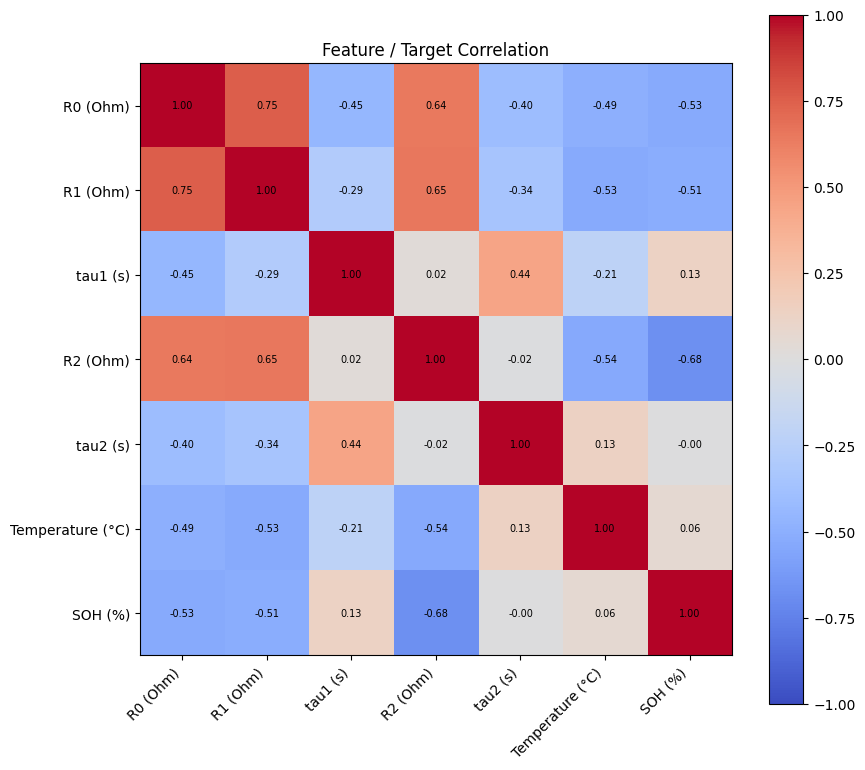

In [16]:
corr = data[FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im); plt.title("Feature / Target Correlation"); plt.tight_layout(); plt.show()

In [17]:
def evaluate(y_true, y_pred, name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)); mae = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred); mape = np.mean(np.abs((y_true-y_pred)/y_true))*100
    print(f"[{name:20s}] RMSE={rmse:6.3f}  MAE={mae:6.3f}  R2={r2:7.4f}  MAPE={mape:5.2f}%")
    return dict(rmse=rmse, mae=mae, r2=r2, mape=mape)

results = {}

## 4. GBDT 基线（全量数据，sklearn，已验证可跑）

`HistGradientBoostingRegressor` 直方图加速，几万行秒级完成、用满全部数据。
可无缝换成 XGBoost / LightGBM（注释里给了）。

In [18]:
# gb = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
#                                    max_depth=None, random_state=RANDOM_SEED)
# gb.fit(X_train_s, y_train)
# results["HistGBDT"] = evaluate(y_test, gb.predict(X_test_s), "HistGBDT")

# 可选: XGBoost / LightGBM (需 pip install)
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=5,
                   subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_SEED)
xgb.fit(X_train_s, y_train); results["XGBoost"] = evaluate(y_test, xgb.predict(X_test_s), "XGBoost")

[XGBoost             ] RMSE= 2.146  MAE= 1.131  R2= 0.9471  MAPE= 1.48%


### 4.1 置换重要性（类似 ARD 的特征相关性，基于 XGBoost）

在测试集上，逐个打乱某特征、看 R² 掉多少 → 掉得越多越重要。这是**基于 XGBoost 学到的依赖关系**，
不代表 MLP 学到的东西——MLP 专属的置换重要性见第 6.1 节，两者要分别看，避免混淆
"数据本身的可预测性"和"MLP 有没有学好"。

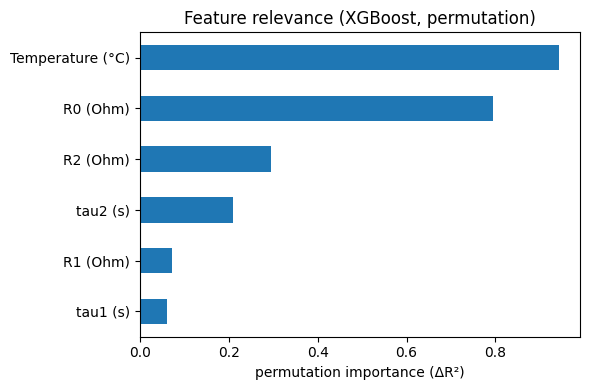

Temperature (°C)    0.9431
R0 (Ohm)            0.7948
R2 (Ohm)            0.2950
tau2 (s)            0.2105
R1 (Ohm)            0.0724
tau1 (s)            0.0614


In [19]:
perm = permutation_importance(xgb, X_test_s, y_test, n_repeats=10,
                              random_state=RANDOM_SEED, scoring="r2")
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
imp.plot(kind="barh"); plt.xlabel("permutation importance (ΔR²)")
plt.title("Feature relevance (XGBoost, permutation)"); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(4).to_string())

## 5. MLP 深度集成（迁移主力，全量数据）

网络拆成 **特征提取器 `feature`** + **回归头 `head`**（迁移时冻结 `feature`、只重训 `head`）。
训练 K 个不同随机种子的模型：**预测 = K 个输出的均值**，**不确定度 = K 个输出的标准差**。

相比最初版本的改动：
- `batch_size` 256→4096 + `ReduceLROnPlateau` 调度器，解决 CPU 上训练根本跑不完的问题；
- `hidden=(128,64,32)`（原 `(256,128,64)`）+ `dropout=0.25`（原 0.1）+ `weight_decay=3e-4`（原 1e-4），
  专门缓解"train R² 很高、test R² 跟不上"的过拟合；
- `BatchNorm` + `GELU` 替换纯 `ReLU`，训练更稳定；
- 记录每个 epoch 的 train/val loss，训练完可以直接画收敛曲线自查。

> 需 `pip install torch`。

In [20]:
# ==================== 目标值标准化 ====================
y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))
yt = y_scaler.transform(y_train.reshape(-1, 1)).ravel()
yv = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
ytest = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

# ==================== 数据加载器 ====================
def to_loader(Xs, ys, bs=4096, shuffle=False):
    """创建PyTorch数据加载器"""
    ds = TensorDataset(
        torch.tensor(Xs, dtype=torch.float32),
        torch.tensor(ys, dtype=torch.float32).view(-1, 1)
    )
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

# ==================== 神经网络模型 ====================
class SOHNet(nn.Module):
    """SOH预测网络"""
    def __init__(self, in_dim=None, hidden=(128, 64, 32), p_drop=0.25):
        super().__init__()
        in_dim = in_dim or len(FEATURES)
        
        self.feature = nn.Sequential(
            nn.Linear(in_dim, hidden[0]),
            nn.BatchNorm1d(hidden[0]),
            nn.GELU(),
            nn.Dropout(p_drop),
            
            nn.Linear(hidden[0], hidden[1]),
            nn.BatchNorm1d(hidden[1]),
            nn.GELU(),
            nn.Dropout(p_drop),
            
            nn.Linear(hidden[1], hidden[2]),
            nn.BatchNorm1d(hidden[2]),
            nn.GELU()
        )
        self.head = nn.Linear(hidden[2], 1)
        
    def forward(self, x):
        return self.head(self.feature(x))

# ==================== 训练函数 ====================
def train_one(seed, epochs=80, lr=2e-3, weight_decay=3e-4, patience=15,
              hidden=(128, 64, 32), p_drop=0.25, init_state=None, 
              only_head=False, verbose=True):
    """训练单个模型"""
    torch.manual_seed(seed)
    
    # 初始化模型
    model = SOHNet(in_dim=len(FEATURES), hidden=hidden, p_drop=p_drop).to(device)
    if init_state:
        model.load_state_dict(init_state)
    
    # 冻结特征层（如果只训练头部）
    if only_head:
        for p in model.feature.parameters():
            p.requires_grad = False
    
    # 优化器
    params = model.head.parameters() if only_head else model.parameters()
    opt = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=5
    )
    loss_fn = nn.MSELoss()
    
    # 数据加载器
    tl = to_loader(X_train_s, yt, shuffle=True)
    vl = to_loader(X_val_s, yv)
    
    # 训练循环
    best_loss = float("inf")
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_loss": []}
    
    for ep in range(epochs):
        # 训练
        model.train()
        tr_loss = 0.0
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= len(tl.dataset)
        
        # 验证
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
        val_loss /= len(vl.dataset)
        
        # 学习率调度
        sched.step(val_loss)
        
        # 记录
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        
        # 打印进度
        if verbose and ep % 5 == 0:
            print(f"  Epoch {ep:3d} | train={tr_loss:.4f} | val={val_loss:.4f} | lr={opt.param_groups[0]['lr']:.2e}")
        
        # 早停
        if val_loss < best_loss - 1e-6:
            best_loss = val_loss
            wait = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    
    # 恢复最佳模型
    if best_state:
        model.load_state_dict(best_state)
    model.history = history
    return model

print("✅ SOHNet 模型与训练函数已就绪")

✅ SOHNet 模型与训练函数已就绪


  Epoch   0 | train=0.1457 | val=0.0361 | lr=2.00e-03
  Epoch   5 | train=0.0338 | val=0.0139 | lr=2.00e-03
  Epoch  10 | train=0.0281 | val=0.0141 | lr=2.00e-03
  Epoch  15 | train=0.0259 | val=0.0248 | lr=1.00e-03
  Epoch  20 | train=0.0243 | val=0.0245 | lr=1.00e-03
  Epoch   0 | train=0.1510 | val=0.0310 | lr=2.00e-03
  Epoch   5 | train=0.0325 | val=0.0159 | lr=2.00e-03
  Epoch  10 | train=0.0275 | val=0.0207 | lr=1.00e-03
  Epoch  15 | train=0.0244 | val=0.0356 | lr=1.00e-03
  Epoch   0 | train=0.1726 | val=0.0460 | lr=2.00e-03
  Epoch   5 | train=0.0337 | val=0.0264 | lr=2.00e-03
  Epoch  10 | train=0.0267 | val=0.0298 | lr=1.00e-03
  Epoch  15 | train=0.0247 | val=0.0339 | lr=1.00e-03
✅ Trained 3 MLP ensemble models
MLP_ensemble(train)  | MAE=0.7736 | RMSE=1.1177 | R²=0.9861
MLP_ensemble(test)   | MAE=1.2225 | RMSE=1.7852 | R²=0.9634

📊 Ensemble prediction uncertainty: 0.343 SOH%


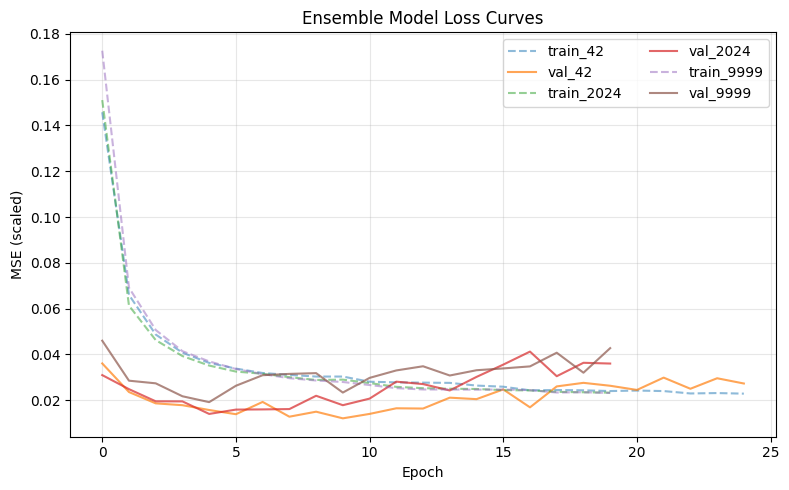

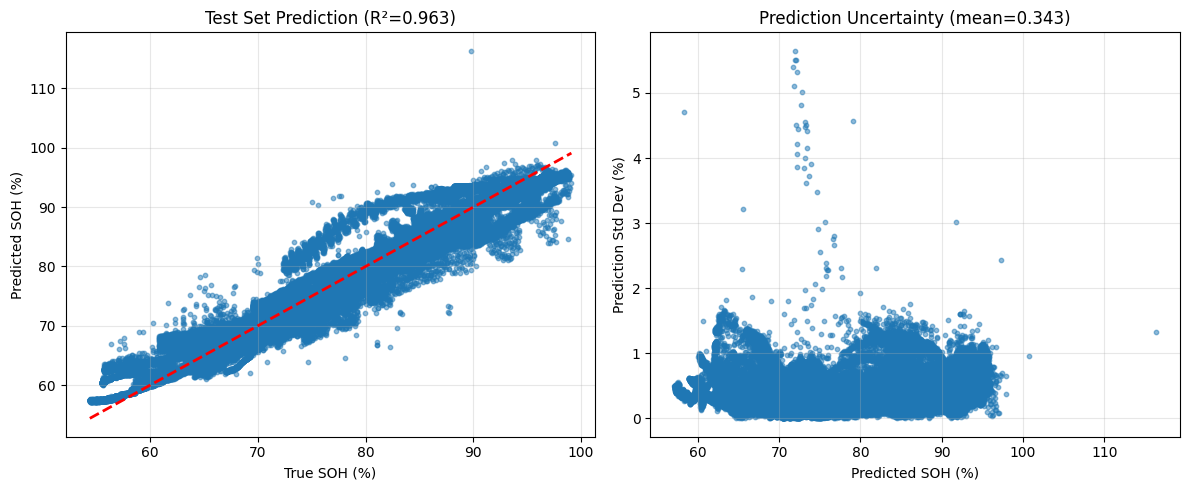


Model Performance Summary
MLP_ensemble_TRAIN        | R²=0.9861 | RMSE=1.1177 | MAE=0.7736
MLP_ensemble              | R²=0.9634 | RMSE=1.7852 | MAE=1.2225


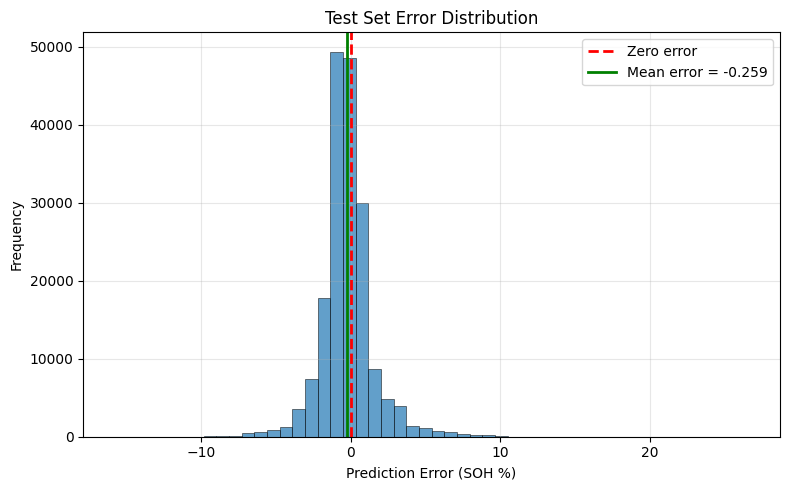


Per-Cell Performance on Test Set
VTC6_020_30SOC_20DOD | MAE=1.3577 | RMSE=1.4803 | R²=0.9578 | n=5349
VTC6_026_30SOC_20DOD | MAE=1.3218 | RMSE=1.7312 | R²=0.9521 | n=6979
VTC6_027_30SOC_20DOD | MAE=0.9752 | RMSE=1.0579 | R²=0.9718 | n=6590
VTC6_033_50SOC_20DOD | MAE=0.6114 | RMSE=0.7734 | R²=0.9877 | n=6585
VTC6_034_50SOC_40DOD | MAE=0.9076 | RMSE=1.2700 | R²=0.9847 | n=4405
VTC6_041_50SOC_40DOD | MAE=1.1630 | RMSE=1.4068 | R²=0.9867 | n=4248
VTC6_046_30SOC_20DOD | MAE=0.7415 | RMSE=0.8591 | R²=0.9844 | n=6594
VTC6_062_30SOC_60DOD | MAE=0.6364 | RMSE=0.9168 | R²=0.9904 | n=2941
VTC6_078_70SOC_60DOD | MAE=0.8973 | RMSE=1.3592 | R²=0.9228 | n=2755
VTC6_084_30SOC_40DOD | MAE=2.6096 | RMSE=3.1579 | R²=0.8852 | n=4520
VTC6_091_30SOC_60DOD | MAE=0.7464 | RMSE=1.0042 | R²=0.9885 | n=2946
VTC6_100_30SOC_60DOD | MAE=0.7886 | RMSE=1.0462 | R²=0.9875 | n=2943
VTC6_102_50SOC_20DOD | MAE=0.8842 | RMSE=1.0053 | R²=0.9724 | n=6591
VTC6_115_50SOC_80DOD | MAE=1.2918 | RMSE=1.8049 | R²=0.9527 | n=2395


In [21]:
# ==================== 集成模型训练 ====================
SEEDS = [42, 2024, 9999]
ensemble = [train_one(seed=s, hidden=(128, 64, 32), p_drop=0.25, weight_decay=3e-4) for s in SEEDS]
print(f"✅ Trained {len(SEEDS)} MLP ensemble models")

# ==================== 集成预测函数 ====================
def ensemble_predict(models, Xs):
    """Ensemble prediction: returns mean and std"""
    preds = []
    for m in models:
        m.eval()
        with torch.no_grad():
            p = m(torch.tensor(Xs, dtype=torch.float32).to(device))
            p = p.cpu().numpy().ravel()
        # Inverse transform to original SOH scale
        preds.append(y_scaler.inverse_transform(p.reshape(-1, 1)).ravel())
    
    P = np.stack(preds)  # (n_models, n_samples)
    return P.mean(0), P.std(0)  # mean=prediction, std=uncertainty

# ==================== 模型评估 ====================
def evaluate(y_true, y_pred, name="Model"):
    """Calculate regression metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} | MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}

results = {}

# 1. Training set evaluation (detect underfitting/overfitting)
mu_train, _ = ensemble_predict(ensemble, X_train_s)
results["MLP_ensemble_TRAIN"] = evaluate(y_train, mu_train, "MLP_ensemble(train)")

# 2. Test set evaluation
mu_test, std_test = ensemble_predict(ensemble, X_test_s)
results["MLP_ensemble"] = evaluate(y_test, mu_test, "MLP_ensemble(test)")

print(f"\n📊 Ensemble prediction uncertainty: {std_test.mean():.3f} SOH%")

# ==================== 损失曲线可视化 ====================
fig, ax = plt.subplots(figsize=(8, 5))

# Plot loss curves for all ensemble members
for i, model in enumerate(ensemble):
    ax.plot(model.history["train_loss"], '--', alpha=0.5, label=f"train_{SEEDS[i]}")
    ax.plot(model.history["val_loss"], '-', alpha=0.7, label=f"val_{SEEDS[i]}")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.set_title("Ensemble Model Loss Curves")
ax.legend(loc="upper right", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== 预测可视化 ====================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True vs Predicted (test set)
axes[0].scatter(y_test, mu_test, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("True SOH (%)")
axes[0].set_ylabel("Predicted SOH (%)")
axes[0].set_title(f"Test Set Prediction (R²={results['MLP_ensemble']['r2']:.3f})")
axes[0].grid(True, alpha=0.3)

# Prediction uncertainty
axes[1].scatter(mu_test, std_test, alpha=0.5, s=10)
axes[1].set_xlabel("Predicted SOH (%)")
axes[1].set_ylabel("Prediction Std Dev (%)")
axes[1].set_title(f"Prediction Uncertainty (mean={std_test.mean():.3f})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 结果汇总 ====================
print("\n" + "="*50)
print("Model Performance Summary")
print("="*50)
for name, metrics in results.items():
    print(f"{name:25s} | R²={metrics['r2']:.4f} | RMSE={metrics['rmse']:.4f} | MAE={metrics['mae']:.4f}")

# ==================== 误差分布 ====================
fig, ax = plt.subplots(figsize=(8, 5))

errors = mu_test - y_test
ax.hist(errors, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(errors.mean(), color='g', linestyle='-', linewidth=2, label=f'Mean error = {errors.mean():.3f}')
ax.set_xlabel("Prediction Error (SOH %)")
ax.set_ylabel("Frequency")
ax.set_title("Test Set Error Distribution")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== 逐电池性能分析 ====================
# Group predictions by cell to see per-battery performance
cell_ids_test = groups[test_mask]
cell_results = {}

for cell_id in np.unique(cell_ids_test):
    mask = cell_ids_test == cell_id
    y_true_cell = y_test[mask]
    y_pred_cell = mu_test[mask]
    
    cell_results[cell_id] = {
        'mae': mean_absolute_error(y_true_cell, y_pred_cell),
        'rmse': np.sqrt(mean_squared_error(y_true_cell, y_pred_cell)),
        'r2': r2_score(y_true_cell, y_pred_cell),
        'n_samples': len(y_true_cell)
    }

# Show per-cell performance
print("\n" + "="*50)
print("Per-Cell Performance on Test Set")
print("="*50)
for cell_id, metrics in sorted(cell_results.items()):
    print(f"{cell_id:15s} | MAE={metrics['mae']:.4f} | RMSE={metrics['rmse']:.4f} | R²={metrics['r2']:.4f} | n={metrics['n_samples']}")

Test Set             | MAE=1.2225 | RMSE=1.7852 | R²=0.9634


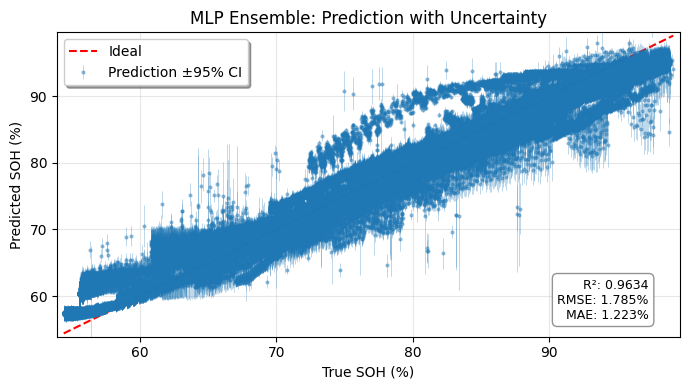


Prediction Error Statistics
Mean Error: -0.2586 SOH%
Std Error:  1.7664 SOH%
Max Error:  26.5818 SOH%
Min Error:  -15.7822 SOH%
95% CI:     [-3.7207, 3.2035]


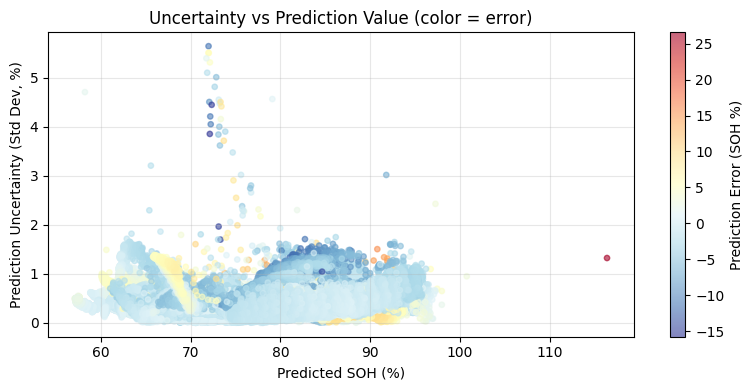

In [22]:
# ==================== 带不确定性的预测可视化 ====================
# 1. 直接调用评估函数
res = evaluate(y_test, mu_test, name="Test Set")

# 2. 提取工况和指标，组合成右下角的文本
info_text = (
    f"R²: {res['r2']:.4f}\n"
    f"RMSE: {res['rmse']:.3f}%\n"
    f"MAE: {res['mae']:.3f}%"
)

# 3. 绘制带不确定性的预测图
idx = np.argsort(y_test)  # 按真实值排序，使曲线更平滑

fig, ax = plt.subplots(figsize=(7, 4))

# 理想线（对角线）
ax.plot(y_test[idx], y_test[idx], "r--", lw=1.5, label="Ideal")

# 预测值 ± 95% 置信区间（1.96 * std）
ax.errorbar(
    y_test[idx], mu_test[idx], 
    yerr=1.96 * std_test[idx], 
    fmt=".", ms=4, capsize=0, alpha=0.4, 
    elinewidth=0.5, label="Prediction ±95% CI"
)

ax.set_xlabel("True SOH (%)")
ax.set_ylabel("Predicted SOH (%)")
ax.set_title("MLP Ensemble: Prediction with Uncertainty")

# 图例放左上角，防止和右下角文本重叠
ax.legend(loc="upper left", frameon=True, fancybox=True, shadow=True)

# 在右下角添加精简信息框
ax.text(
    0.95, 0.05, info_text, 
    transform=ax.transAxes, 
    ha="right", va="bottom", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="gray")
)

# 设置坐标轴范围，使图形更美观
ax.set_xlim(y_test.min() - 0.5, y_test.max() + 0.5)
ax.set_ylim(y_test.min() - 0.5, y_test.max() + 0.5)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== 补充：显示预测误差统计 ====================
errors = mu_test - y_test
print("\n" + "="*50)
print("Prediction Error Statistics")
print("="*50)
print(f"Mean Error: {errors.mean():.4f} SOH%")
print(f"Std Error:  {errors.std():.4f} SOH%")
print(f"Max Error:  {errors.max():.4f} SOH%")
print(f"Min Error:  {errors.min():.4f} SOH%")
print(f"95% CI:     [{errors.mean() - 1.96*errors.std():.4f}, {errors.mean() + 1.96*errors.std():.4f}]")

# ==================== 补充：预测不确定性分布 ====================
fig, ax = plt.subplots(figsize=(8, 4))

# 显示不确定性随预测值的变化
scatter = ax.scatter(mu_test, std_test, c=errors, cmap='RdYlBu_r', alpha=0.6, s=15)
ax.set_xlabel("Predicted SOH (%)")
ax.set_ylabel("Prediction Uncertainty (Std Dev, %)")
ax.set_title("Uncertainty vs Prediction Value (color = error)")
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Prediction Error (SOH %)")
plt.tight_layout()
plt.show()

## 6. 诊断补充

### 6.1 MLP 专属置换重要性

第 4.1 节的置换重要性是基于 XGBoost 算的，这里单独对 MLP 集成算一次，两者对照看，
才能确认 MLP 是不是真的学到了合理的特征依赖（尤其关注 `d_*` 变化量特征是否排到前面——
如果是，说明模型学的是"衰减了多少"而不是"记住电池身份"）。

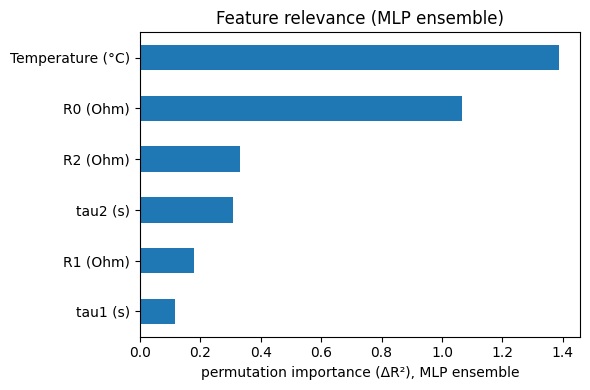

Temperature (°C)    1.3873
R0 (Ohm)            1.0649
R2 (Ohm)            0.3309
tau2 (s)            0.3085
R1 (Ohm)            0.1780
tau1 (s)            0.1156


In [23]:
def mlp_permutation_importance(models, X, y, n_repeats=10, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    base_mu, _ = ensemble_predict(models, X)
    base_r2 = r2_score(y, base_mu)
    importances = np.zeros((n_repeats, X.shape[1]))
    for r in range(n_repeats):
        for j in range(X.shape[1]):
            Xp = X.copy()
            rng.shuffle(Xp[:, j])
            mu_p, _ = ensemble_predict(models, Xp)
            importances[r, j] = base_r2 - r2_score(y, mu_p)
    return pd.Series(importances.mean(0), index=FEATURES).sort_values()

imp_mlp = mlp_permutation_importance(ensemble, X_test_s, y_test)
imp_mlp.plot(kind="barh"); plt.xlabel("permutation importance (ΔR²), MLP ensemble")
plt.title("Feature relevance (MLP ensemble)"); plt.tight_layout(); plt.show()
print(imp_mlp.sort_values(ascending=False).round(4).to_string())

### 6.2 关键特征的噪声敏感度检查

如果置换重要性显示模型对某个特征（例如 `d_R0 (Ohm)`）依赖过重，就值得检查一下：
给这个特征加不同强度的高斯噪声，看 test R² 掉多少。如果小幅噪声就让 R² 明显下滑，
说明模型"押宝"押得有点重，对该特征的测量误差比较敏感，可以考虑训练时对它做数据增强
（随机加小噪声），逼模型多用一点次要信号，泛化会更稳。

In [24]:
# 给 R0 加不同强度的高斯噪声，评估对测量误差的敏感度
target_col = "R0 (Ohm)"
col_idx = FEATURES.index(target_col)
noise_std = X_test_s[:, col_idx].std()
for noise_level in [0.0, 0.1, 0.3, 0.5, 1.0]:
    Xn = X_test_s.copy()
    Xn[:, col_idx] += np.random.default_rng(0).normal(0, noise_level * noise_std, size=len(Xn))
    mu_n, _ = ensemble_predict(ensemble, Xn)
    print(f"noise={noise_level:.1f}x std on {target_col} -> test R2={r2_score(y_test, mu_n):.4f}")


noise=0.0x std on R0 (Ohm) -> test R2=0.9634
noise=0.1x std on R0 (Ohm) -> test R2=0.9165
noise=0.3x std on R0 (Ohm) -> test R2=0.6158
noise=0.5x std on R0 (Ohm) -> test R2=0.1914
noise=1.0x std on R0 (Ohm) -> test R2=-1.2925


### 6.3 定位误差最大的样本：按电池 vs 按 SOH 区间

预测散点图上如果出现"炸开"的离群点，需要判断这是**少数几块电池数据有问题**，
还是**某个 SOH 区间对所有电池来说都更难预测**。两种情况的应对完全不同：前者该清洗/复核数据，
后者该做样本加权或补充能区分老化路径的特征。

注意：**只看均值容易被样本量大的区间"稀释"、掩盖局部离群点**——同时看"大误差样本占比"和
"95 分位误差"，比单看均值更能反映真实的局部失败情况。

In [25]:
resid = np.abs(y_test - mu_test)

# 1) 严格 top-200，看真正误差最大的点是不是集中在少数电池上
worst200 = np.argsort(-resid)[:200]
print("Top-200 最差样本的电池分布：")
worst_cell_counts = data.iloc[test_idx[worst200]]["cell_id"].value_counts()

print(worst_cell_counts.head(10))

flagged_cells = set(worst_cell_counts.head(5).index)
print(f"\n✅ 动态提取的问题电池集合 (Top 5): {flagged_cells}")

# 2) 按 SOH 分桶：均值 + 大误差样本占比 + 95 分位误差
soh_bins = pd.cut(y_test, bins=[50, 60, 70, 80, 90, 100])
df_r = pd.DataFrame({"resid": resid, "bin": soh_bins})

print("\n按 SOH 区间统计的平均绝对误差：")
print(df_r.groupby("bin")["resid"].agg(["mean", "count"]))

big_miss = df_r.assign(big=lambda d: d["resid"] > 5).groupby("bin")["big"].agg(["sum", "mean", "count"])
big_miss.columns = ["大误差样本数(>5%)", "占该区间比例", "该区间总样本数"]
print("\n大误差样本占比（比均值更能反映局部离群，不被大样本量区间稀释）：")
print(big_miss)

p95 = df_r.groupby("bin")["resid"].quantile(0.95)
print("\n各区间 95 分位误差：")
print(p95)

Top-200 最差样本的电池分布：
cell_id
VTC6_206_50SOC_20DOD    104
VTC6_277_30SOC_60DOD     58
VTC6_078_70SOC_60DOD      5
VTC6_201_50SOC_80DOD      5
VTC6_189_30SOC_20DOD      4
VTC6_084_30SOC_40DOD      3
VTC6_157_50SOC_40DOD      3
VTC6_062_30SOC_60DOD      2
VTC6_100_30SOC_60DOD      2
VTC6_139_70SOC_60DOD      2
Name: count, dtype: int64

✅ 动态提取的问题电池集合 (Top 5): {'VTC6_277_30SOC_60DOD', 'VTC6_201_50SOC_80DOD', 'VTC6_206_50SOC_20DOD', 'VTC6_189_30SOC_20DOD', 'VTC6_078_70SOC_60DOD'}

按 SOH 区间统计的平均绝对误差：
               mean  count
bin                       
(50, 60]   2.338635   5169
(60, 70]   1.449307  20774
(70, 80]   1.059755  66299
(80, 90]   1.078861  59872
(90, 100]  1.519098  30059

大误差样本占比（比均值更能反映局部离群，不被大样本量区间稀释）：
           大误差样本数(>5%)    占该区间比例  该区间总样本数
bin                                      
(50, 60]           622  0.120333     5169
(60, 70]           471  0.022673    20774
(70, 80]           960  0.014480    66299
(80, 90]          1472  0.024586    59872
(90, 100]          983  0.0

In [26]:
# 检查当前已定义的变量
print("Defined variables:", dir())
print("x_scaler" in dir())  # 检查是否存在

Defined variables: ['DATA_ROOT', 'DataLoader', 'FEATURES', 'GroupKFold', 'GroupShuffleSplit', 'HAS_TORCH', 'In', 'LOG_TAU_COLS', 'Out', 'Path', 'RANDOM_SEED', 'RANDOM_SPLIT_BY_CELL', 'RANDOM_TEST_RATIO', 'RANDOM_VAL_RATIO', 'SEEDS', 'SOHNet', 'StandardScaler', 'TARGET', 'TEMPERATURE_COL', 'TIME_RE', 'TensorDataset', 'USE_LOG_TAU', 'X', 'XGBRegressor', 'X_test', 'X_test_s', 'X_train', 'X_train_s', 'X_val', 'X_val_s', 'Xn', '_', '_14', '_4', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'ax', 'axes', 'big_miss', 'cbar', 'cell_id', 'cell_ids_test', 'cell_results', 'cleaned', 'col', 'col_idx', 'corr', 'data', 'datetime', 'device', 'df', 'df_r', 'ensemble', 'ensemble_pred

## 7. 保存模型与预处理器（迁移学习的输入）

这一步会把 **MLP 集成权重 + `x_scaler` / `y_scaler` + 特征定义 + 网络结构** 一起存到
`./nca_artifacts/`。迁移学习 notebook `lfp_transfer_learning.ipynb` 直接读这两个文件，
所以 **跑迁移之前必须先跑完这一格**。


In [27]:
# ============================================================
# Save NCA pretraining artifacts for transfer learning
# (to be loaded by lfp_transfer_learning.ipynb)
# ============================================================
import joblib
# 将 scaler 赋值给 x_scaler（因为检查显示 scaler 已存在）
x_scaler = scaler

# 然后执行保存代码（同上）

SAVE_DIR = Path("./nca_artifacts")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MLP_HIDDEN = (128, 64, 32)
MLP_DROPOUT = 0.25

# 1) Save CPU weights for each ensemble member (portable across GPU/CPU)
torch.save(
    {
        f"member_{i}": {k: v.detach().cpu() for k, v in m.state_dict().items()}
        for i, m in enumerate(ensemble)
    },
    SAVE_DIR / "nca_mlp_ensemble.pt"
)

# 2) Save preprocessors, hyperparams, and split info
# (transfer learning requires identical feature engineering)
joblib.dump({
    "features": FEATURES,
    "target": TARGET,
    "temperature_col": TEMPERATURE_COL,
    "use_log_tau": USE_LOG_TAU,
    "log_tau_cols": LOG_TAU_COLS,
    "x_scaler": x_scaler,
    "y_scaler": y_scaler,
    "hidden": MLP_HIDDEN,
    "p_drop": MLP_DROPOUT,
    "in_dim": len(FEATURES),
    "n_members": len(ensemble),
    "seeds": SEEDS,
}, SAVE_DIR / "nca_mlp_pre.joblib")

print(f"✅ Saved NCA pretraining artifacts to {SAVE_DIR.resolve()}")
print("   - nca_mlp_ensemble.pt   (weights of K ensemble members)")
print("   - nca_mlp_pre.joblib    (x_scaler / y_scaler / features / network config)")

# Optional: GBDT baseline (not used for transfer learning)
# joblib.dump({
#     "features": FEATURES,
#     "use_log_tau": USE_LOG_TAU,
#     "log_tau_cols": LOG_TAU_COLS,
#     "x_scaler": x_scaler,
#     "gbdt": xgb
# }, SAVE_DIR / "nca_gbdt.joblib")

✅ Saved NCA pretraining artifacts to C:\Users\huang\Downloads\nca_artifacts
   - nca_mlp_ensemble.pt   (weights of K ensemble members)
   - nca_mlp_pre.joblib    (x_scaler / y_scaler / features / network config)


## 8. 迁移到 LFP

迁移学习的完整代码已经**单独放在 `lfp_transfer_learning.ipynb`**，包含四组对照实验：
Zero-shot / Head-only / Full fine-tune / Scratch。本 notebook 只负责产出预训练权重
（第 7 节），下面这格保留作占位说明。


In [28]:
# 迁移学习代码已迁出到独立文件：lfp_transfer_learning.ipynb
# 使用步骤：
#   1) 先跑完本 notebook 的第 7 节，确认 ./nca_artifacts/ 下已生成
#      nca_mlp_ensemble.pt 和 nca_mlp_pre.joblib
#   2) 打开 lfp_transfer_learning.ipynb，把 LFP_DATA_ROOT 改成你的 LFP 目标域数据根目录
#   3) 依次运行，即可得到 Zero-shot / Head-only / Full fine-tune / Scratch 四组结果对比
print("迁移学习请打开 lfp_transfer_learning.ipynb")


迁移学习请打开 lfp_transfer_learning.ipynb


## 9. 原始 MLP vs Temporal Transformer + MLP

本节将保留原始 MLP，并使用同一组电池级划分训练时序模型进行对比。
默认把一个数据文件聚合为一个时间步；如果一个文件本身就是一个时间点，请将 `SEQUENCE_UNIT` 改为 `"row"`。
必须先按 `cell_id` 划分，再在各集合内部生成窗口，避免相邻窗口重叠造成数据泄漏。

In [35]:
# ==================== Temporal Transformer 数据准备 ====================
SEQ_LEN = 32
SEQ_STRIDE = 8
SEQUENCE_UNIT = "row"  # "file" 或 "row"
SEQUENCE_AGGREGATION = "mean"
SEQ_BATCH_SIZE = 512

n_features = len(FEATURES)

# 沿用前面按电池得到的 train/val/test 划分；不重新随机划分窗口
train_cells = set(np.unique(groups[train_idx]))
val_cells = set(np.unique(groups[val_idx]))
test_cells = set(np.unique(groups[test_idx]))
assert train_cells.isdisjoint(val_cells)
assert train_cells.isdisjoint(test_cells)
assert val_cells.isdisjoint(test_cells)

def _prepare_time_steps(frame, unit=SEQUENCE_UNIT):
    """
    整理时序数据。

    row 模式：
        一个 segment 是一个时间步。
        时间顺序 = cell_id → file_order → segment_id。

    file 模式：
        一个文件聚合成一个时间步。
    """
    frame = frame.copy()

    if "segment_id" not in frame.columns:
        raise KeyError(
            "数据中没有找到 segment_id 列。"
            f"实际列名为：{frame.columns.tolist()}"
        )

    # segment_id 在每个文件内都会重新从 1 开始，
    # 因此必须结合 file_order 使用，不能单独全局排序。
    frame["segment_id_num"] = pd.to_numeric(
        frame["segment_id"],
        errors="coerce"
    )

    if frame["segment_id_num"].isna().any():
        bad = frame.loc[
            frame["segment_id_num"].isna(),
            ["cell_id", "file_order", "segment_id"]
        ].head(20)

        raise ValueError(
            "segment_id 中存在无法转换为数字的值：\n"
            f"{bad.to_string(index=False)}"
        )

    # 关键顺序：
    # 1. 同一块电池
    # 2. 文件从早到晚
    # 3. 文件内部 segment 从小到大
    frame = frame.sort_values(
        ["cell_id", "file_order", "segment_id_num"],
        kind="stable"
    )

    if unit == "row":
        # 一个 segment 就是一个时间步。
        # 不要按 source_file 分组，这样窗口可以跨文件。
        return frame

    if unit != "file":
        raise ValueError(
            "SEQUENCE_UNIT 必须是 'file' 或 'row'"
        )

    # file 模式：一个文件聚合成一个时间步
    agg = {
        c: SEQUENCE_AGGREGATION
        for c in FEATURES + [TARGET]
    }

    steps = (
        frame
        .groupby(
            ["cell_id", "file_order", "source_file"],
            as_index=False,
            sort=False
        )
        .agg(agg)
    )

    return steps.sort_values(
        ["cell_id", "file_order"],
        kind="stable"
    )


def make_temporal_windows(frame, seq_len=SEQ_LEN, stride=SEQ_STRIDE):
    steps = _prepare_time_steps(frame)
    X_windows, y_windows, window_cells = [], [], []

    for cell_id, g in steps.groupby("cell_id", sort=False):
        values = g[FEATURES].to_numpy(dtype=np.float32)
        targets = g[TARGET].to_numpy(dtype=np.float32)
        if len(values) < seq_len:
            continue

        for start in range(0, len(values) - seq_len + 1, stride):
            end = start + seq_len
            X_windows.append(values[start:end])
            # 多对一预测：使用窗口时间的平均 SOH
            y_windows.append(targets[start:end].mean())
            window_cells.append(cell_id)

    if not X_windows:
        raise RuntimeError("没有生成时序窗口，请减小 SEQ_LEN 或检查数据时间步")

    return (
        np.stack(X_windows).astype(np.float32),
        np.asarray(y_windows, dtype=np.float32),
        np.asarray(window_cells)
    )

train_frame = data[data["cell_id"].isin(train_cells)].copy()
val_frame = data[data["cell_id"].isin(val_cells)].copy()
test_frame = data[data["cell_id"].isin(test_cells)].copy()

X_seq_train_raw, y_seq_train, seq_groups_train = make_temporal_windows(train_frame)
X_seq_val_raw, y_seq_val, seq_groups_val = make_temporal_windows(val_frame)
X_seq_test_raw, y_seq_test, seq_groups_test = make_temporal_windows(test_frame)

# 时序模型单独 fit scaler，但仍然只使用训练电池
seq_scaler = StandardScaler().fit(X_seq_train_raw.reshape(-1, n_features))

def scale_sequence_array(x):
    shape = x.shape
    return seq_scaler.transform(x.reshape(-1, n_features)).reshape(shape).astype(np.float32)

X_seq_train = scale_sequence_array(X_seq_train_raw)
X_seq_val = scale_sequence_array(X_seq_val_raw)
X_seq_test = scale_sequence_array(X_seq_test_raw)

seq_y_scaler = StandardScaler().fit(y_seq_train.reshape(-1, 1))
yt_seq = seq_y_scaler.transform(y_seq_train.reshape(-1, 1)).ravel()
yv_seq = seq_y_scaler.transform(y_seq_val.reshape(-1, 1)).ravel()
ytest_seq = seq_y_scaler.transform(y_seq_test.reshape(-1, 1)).ravel()

print("Temporal data ready")
print(f"SEQUENCE_UNIT={SEQUENCE_UNIT} | seq_len={SEQ_LEN} | stride={SEQ_STRIDE}")
print(f"train={X_seq_train.shape}, val={X_seq_val.shape}, test={X_seq_test.shape}")
print(f"window cells: train={len(np.unique(seq_groups_train))}, val={len(np.unique(seq_groups_val))}, test={len(np.unique(seq_groups_test))}")

Temporal data ready
SEQUENCE_UNIT=row | seq_len=32 | stride=8
train=(65999, 32, 6), val=(23470, 32, 6), test=(22612, 32, 6)
window cells: train=138, val=46, test=46


In [36]:
# ==================== Temporal Transformer + MLP ====================
class TemporalTransformerSOHNet(nn.Module):
    def __init__(self, in_dim, seq_len, d_model=64, nhead=4,
                 num_layers=2, dim_ff=128, p_drop=0.10):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=p_drop, activation="gelu",
            batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, sequence_length, feature_dim)
        z = self.input_proj(x)
        z = z + self.pos_embed[:, :x.size(1), :]
        z = self.encoder(z)
        # 多对一：用窗口时间步预测平均 SOH
        return self.head(z.mean(dim=1))

def train_temporal_one(seed, epochs=50, lr=1e-3, weight_decay=3e-4,
                       patience=10, d_model=64, nhead=4,
                       num_layers=2, dim_ff=128, p_drop=0.10,
                       verbose=True):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = TemporalTransformerSOHNet(
        in_dim=n_features, seq_len=SEQ_LEN, d_model=d_model,
        nhead=nhead, num_layers=num_layers, dim_ff=dim_ff, p_drop=p_drop
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=4
    )
    loss_fn = nn.MSELoss()
    train_loader = to_loader(X_seq_train, yt_seq, bs=SEQ_BATCH_SIZE, shuffle=True)
    val_loader = to_loader(X_seq_val, yv_seq, bs=SEQ_BATCH_SIZE)

    best_loss = float("inf")
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_loss": []}

    for ep in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)
        sched.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if verbose and ep % 5 == 0:
            print(f"  Epoch {ep:3d} | train={train_loss:.4f} | val={val_loss:.4f}")

        if val_loss < best_loss - 1e-6:
            best_loss = val_loss
            wait = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.history = history
    return model

def temporal_ensemble_predict(models, Xs):
    preds = []
    x_tensor = torch.tensor(Xs, dtype=torch.float32).to(device)
    for model in models:
        model.eval()
        with torch.no_grad():
            pred_scaled = model(x_tensor).cpu().numpy().ravel()
        preds.append(seq_y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel())
    pred_matrix = np.stack(preds)
    return pred_matrix.mean(axis=0), pred_matrix.std(axis=0)

TEMPORAL_SEEDS = [42, 2024, 9999]
temporal_ensemble = [
    train_temporal_one(seed=s, verbose=False)
    for s in TEMPORAL_SEEDS
]
print(f"✅ Trained {len(temporal_ensemble)} Temporal Transformer models")

C:\Users\huang\AppData\Local\Temp\ipykernel_16600\4240204953.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


✅ Trained 3 Temporal Transformer models


Temporal Transformer(test) | MAE=0.7675 | RMSE=1.2489 | R²=0.9818

Model comparison on held-out batteries
                               MAE    RMSE      R2
MLP (row-wise)              1.2225  1.7852  0.9634
Temporal Transformer + MLP  0.7675  1.2489  0.9818


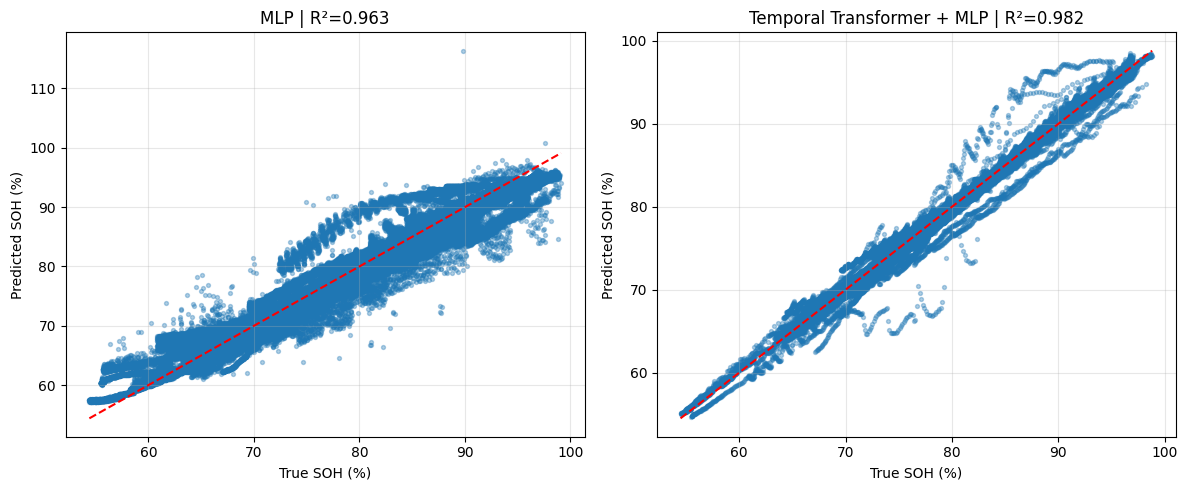

✅ Saved temporal artifacts to C:\Users\huang\Downloads\nca_artifacts\temporal_transformer


In [37]:
# ==================== 统一对比：原始 MLP vs Temporal Transformer ====================
mu_temporal_test, std_temporal_test = temporal_ensemble_predict(
    temporal_ensemble, X_seq_test
)

temporal_metrics = evaluate(
    y_seq_test, mu_temporal_test, "Temporal Transformer(test)"
)

comparison = pd.DataFrame({
    "MLP (row-wise)": results["MLP_ensemble"],
    "Temporal Transformer + MLP": temporal_metrics
}).T[["mae", "rmse", "r2"]]
comparison.columns = ["MAE", "RMSE", "R2"]
print("\nModel comparison on held-out batteries")
print(comparison.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, mu_test, alpha=0.35, s=8)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title(f"MLP | R²={results['MLP_ensemble']['r2']:.3f}")
axes[0].set_xlabel("True SOH (%)")
axes[0].set_ylabel("Predicted SOH (%)")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_seq_test, mu_temporal_test, alpha=0.35, s=8)
axes[1].plot([y_seq_test.min(), y_seq_test.max()], [y_seq_test.min(), y_seq_test.max()], "r--")
axes[1].set_title(f"Temporal Transformer + MLP | R²={temporal_metrics['r2']:.3f}")
axes[1].set_xlabel("True SOH (%)")
axes[1].set_ylabel("Predicted SOH (%)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 保存时序模型及其独立预处理器，便于后续迁移
import joblib
TEMPORAL_SAVE_DIR = Path("./nca_artifacts/temporal_transformer")
TEMPORAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        f"member_{i}": {k: v.detach().cpu() for k, v in model.state_dict().items()}
        for i, model in enumerate(temporal_ensemble)
    },
    TEMPORAL_SAVE_DIR / "nca_temporal_transformer_ensemble.pt"
)
joblib.dump({
    "features": FEATURES,
    "target": TARGET,
    "seq_len": SEQ_LEN,
    "seq_stride": SEQ_STRIDE,
    "sequence_unit": SEQUENCE_UNIT,
    "d_model": 64,
    "nhead": 4,
    "num_layers": 2,
    "dim_ff": 128,
    "p_drop": 0.10,
    "n_members": len(temporal_ensemble),
    "seq_scaler": seq_scaler,
    "seq_y_scaler": seq_y_scaler,
}, TEMPORAL_SAVE_DIR / "nca_temporal_transformer_pre.joblib")
print(f"✅ Saved temporal artifacts to {TEMPORAL_SAVE_DIR.resolve()}")